#  Will they stay in our bank or choose an other one? Deep Learning Approach
- Author : Nasik Rehman 
- linkIn:
- Github:
- twitter:

# AIM: `We wiil classifiy the customaers who will stay in our banl or leave the bank using deep learning approach. `

`Data Description:`
- Customer ID: A unique identifier for each customer

- Surname: The customer's surname or last name

- Credit Score: A numerical value representing the customer's credit score

- Geography: The country where the customer resides

- Gender: The customer's gender

- Age: The customer's age.

- Tenure: The number of years the customer has been with the bank

- Balance: The customer's account balance

- NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)

- HasCrCard: Whether the customer has a credit card

- IsActiveMember: Whether the customer is an active member

- EstimatedSalary: The estimated salary of the customer

- Exited: Whether the customer has churned (Target Variable)



In [1]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.pipeline import Pipeline

 



In [2]:
# load the dataset
df_train = pd.read_csv('D:/python_for_data_science/assigment and projects/datasets/bank_churn_dataset/train.csv')
df_test = pd.read_csv('D:/python_for_data_science/assigment and projects/datasets/bank_churn_dataset/test.csv')
submission = pd.read_csv('D:/python_for_data_science/assigment and projects/datasets/bank_churn_dataset/sample_submission.csv')

In [3]:
# train dataset and exploration
df_train.head().T

,0,1,2,3,4
id,0,1,2,3,4
CustomerId,15674932,15749177,15694510,15741417,15766172
Surname,Okwudilichukwu,Okwudiliolisa,Hsueh,Kao,Chiemenam
CreditScore,668,627,678,581,716
Geography,France,France,France,France,Spain
Gender,Male,Male,Male,Male,Male
Age,33.0,33.0,40.0,34.0,33.0
Tenure,3,1,10,2,5
Balance,0.0,0.0,0.0,148882.54,0.0
NumOfProducts,2,2,2,1,2


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


In [6]:
df_train.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
cat_cols = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'Exited']

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# find the value counts of the categorical columns
for col in cat_cols:
    print(df_train[col].value_counts())
    print()


Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender
Male      93150
Female    71884
Name: count, dtype: int64

Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

Exited
0    130113
1     34921
Name: count, dtype: int64



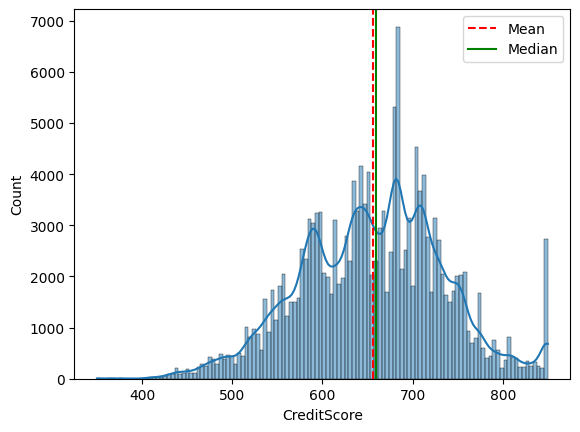

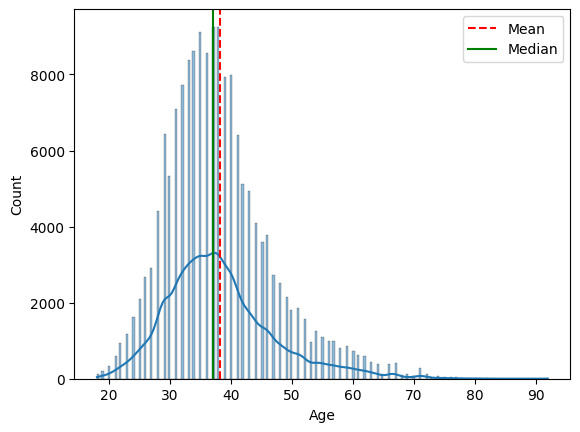

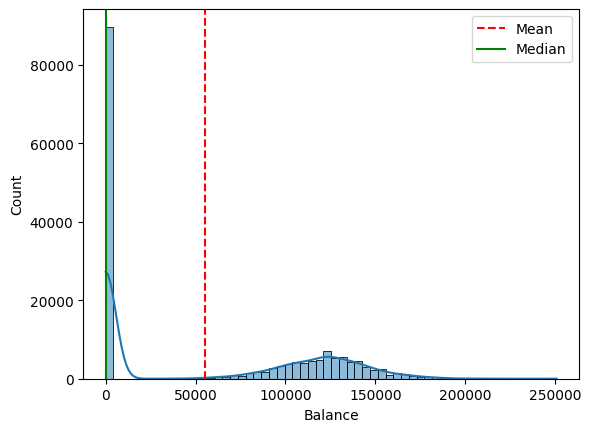

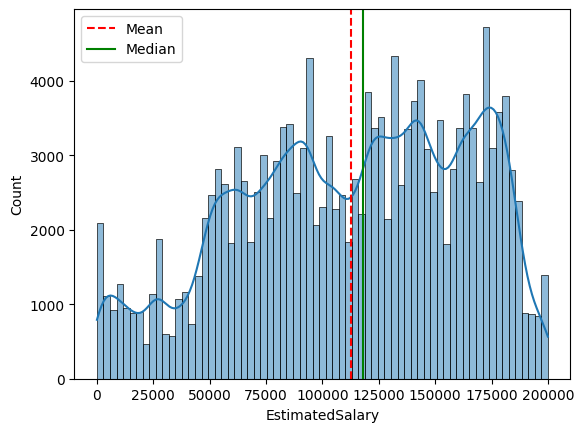

In [8]:
# create a histogram of numeric columns using sns and kde=True
for col in num_cols:
    sns.histplot(df_train[col], kde=True)
    plt.axvline(df_train[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df_train[col].median(), color='green', linestyle='-', label='Median')
    plt.legend()
    plt.show()

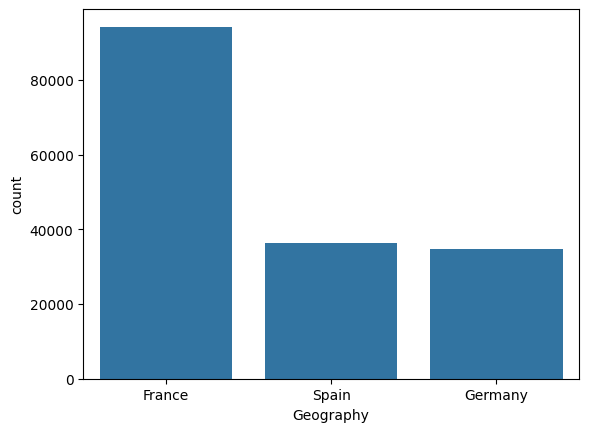

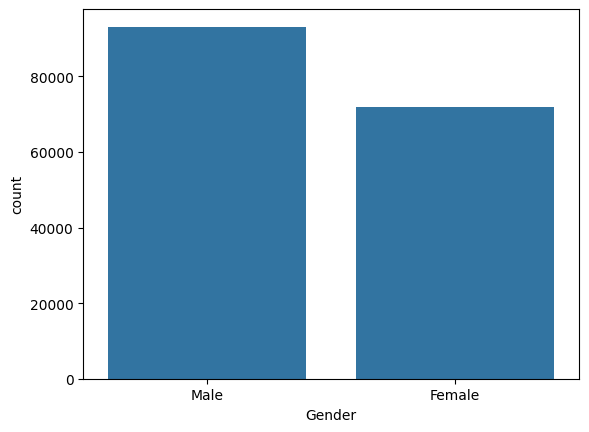

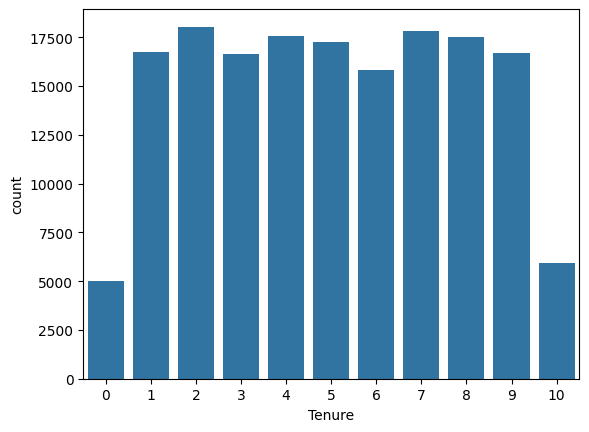

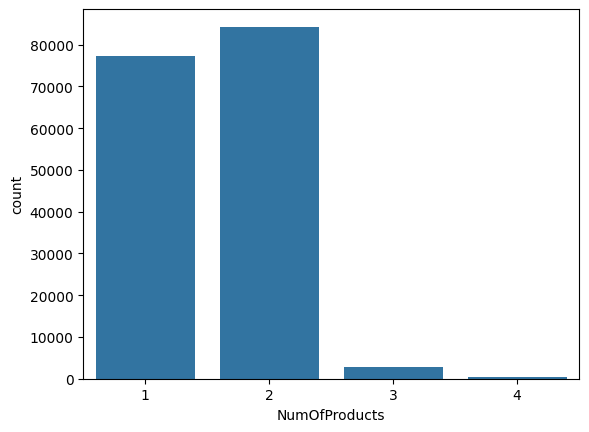

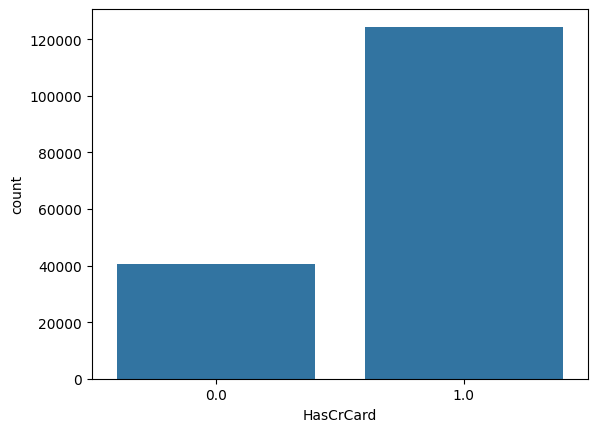

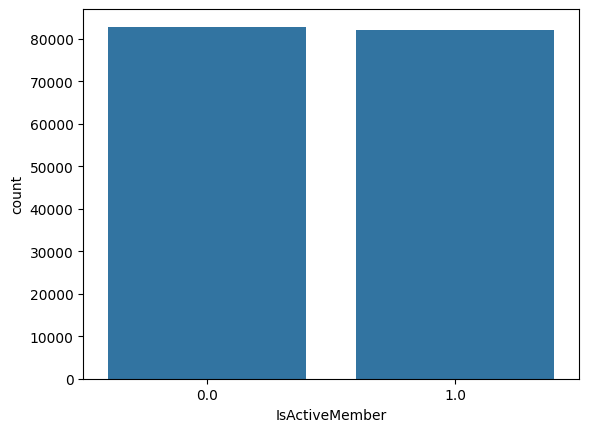

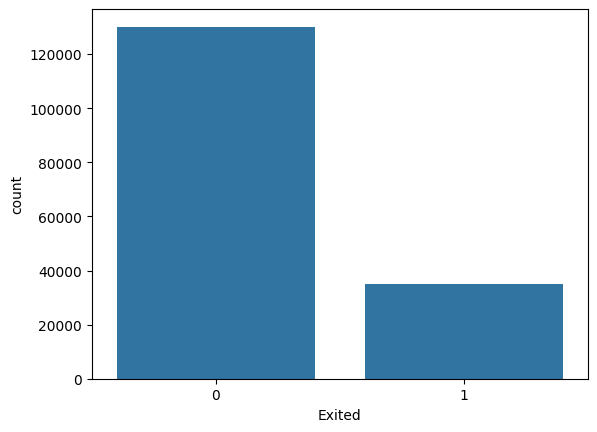

In [9]:
# create a count plot for each column
for col in cat_cols:
    sns.countplot(df_train, x = df_train[col])
    plt.show()


In [10]:
# print the number of rows and columns 
print(f'The train dataset has {df_train.shape[0]} rows and {df_train.shape[1]} columns')

The train dataset has 165034 rows and 14 columns


In [11]:
df_train['Geography'] = le.fit_transform(df_train['Geography'])
df_train['Gender'] = le.fit_transform(df_train['Gender'])

NameError: name 'le' is not defined

In [ ]:
# split the data into X and y
X = df_train.drop(["Exited",'id','CustomerId','Surname'],axis=1)
y = df_train["Exited"]

# encode the categorical columns having object dtype using LabelEncoder
le = LabelEncoder()
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = le.fit_transform(X[col])

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create a pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

# fit the pipeline
pipeline.fit(X_train, y_train)

# make predictions
y_pred = pipeline.predict(X_test)

# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97
1,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50
2,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69
3,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88
4,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83


In [ ]:
y.value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

Epoch 1/5
4126/4126 [==============================] - 79s 18ms/step - loss: 16.4037 - accuracy: 0.6866 - val_loss: 0.7766 - val_accuracy: 0.5932
Epoch 2/5
4126/4126 [==============================] - 66s 16ms/step - loss: 1.2345 - accuracy: 0.7394 - val_loss: 1.0673 - val_accuracy: 0.5878
Epoch 3/5
4126/4126 [==============================] - 57s 14ms/step - loss: 0.6951 - accuracy: 0.7767 - val_loss: 0.5149 - val_accuracy: 0.7893
Epoch 4/5
4126/4126 [==============================] - 57s 14ms/step - loss: 0.7538 - accuracy: 0.7858 - val_loss: 0.5150 - val_accuracy: 0.7893
Epoch 5/5
4126/4126 [==============================] - 58s 14ms/step - loss: 0.5164 - accuracy: 0.7882 - val_loss: 0.5149 - val_accuracy: 0.7893


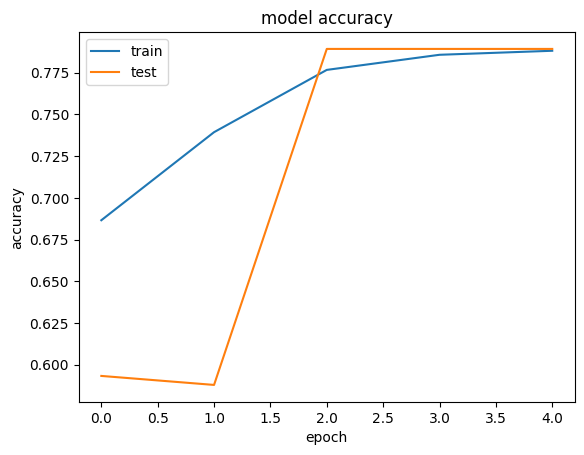

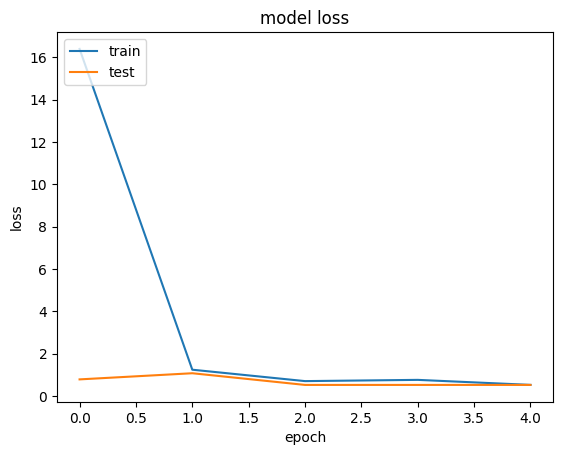

In [36]:
# create a deep neural network using tensorflow and keras for binary classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build the model
model =tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# EarlyStopping
early_stopping = EarlyStopping(patience=15)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# plot the training and testing loss and accuracy at each epoch
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()